In [1]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import torch as t
import seaborn as sns

In [2]:
l3_model_path = 'meta-llama/Llama-3.2-3B-Instruct'
g2_model_path = 'google/gemma-2-2b-it'
q8_model_path = 'Qwen/Qwen3-8B'

In [3]:
graph_type = 'simple'

def load_file_get_metrics(f_path):
    with open(f_path, 'r') as f:
        scores = json.load(f)
        gen_diff_mean, gen_diff_std = scores['gen_diff']['overall']['mean'], scores['gen_diff']['overall']['std']
    scores = {
        'gen_diff': (gen_diff_mean, gen_diff_std)
    }
    return scores

def format_label(metric, steer_type, harm_type):
    metric_label = 'dirKL' if metric.startswith('dkl') else metric
    steer_label = 'steered' if steer_type == 'steer' else steer_type
    return f"{metric_label} | {steer_label} | {harm_type}"

def get_all_scores(model_path, n, learn_type, metric_types, steer_types, harm_types):
    dir_path = f"circuits/{model_path.split('/')[-1]}"
    all_scores = defaultdict(list)
    for metric in metric_types:
        for steer_type in steer_types:
            for harm_type in harm_types:
                exp_name = f"{learn_type}{metric}_{steer_type}_{harm_type}"
                label = format_label(metric, steer_type, harm_type)

                f_faith = f"faithfulness_{n}_{graph_type}_harmless.json"
                f_path = os.path.join(dir_path, exp_name, f_faith)
                if os.path.exists(f_path):
                    scores_harmless = load_file_get_metrics(f_path)
                    all_scores['gen_diff_harmless'].append((exp_name, scores_harmless['gen_diff'][0], scores_harmless['gen_diff'][1], label))
                else:
                    print(f'{f_path} does not exist')

                f_faith = f"faithfulness_{n}_{graph_type}_harmful.json"
                f_path = os.path.join(dir_path, exp_name, f_faith)
                if os.path.exists(f_path):
                    scores_harmful = load_file_get_metrics(f_path)
                    all_scores['gen_diff_harmful'].append((exp_name, scores_harmful['gen_diff'][0], scores_harmful['gen_diff'][1], label))
                else:
                    print(f'{f_path} does not exist')
    return all_scores

def get_scores(f):
    if os.path.exists(f):
        scores = load_file_get_metrics(f)
    
    return scores['gen_diff'][0], scores['gen_diff'][1]

In [4]:
def get_n_scores(model_path, ns, exp_name, method='simple', invert=False):
    if os.path.exists(f"../circuits/{model_path.split('/')[-1]}/{exp_name}"):
        dir_path = f"../circuits/{model_path.split('/')[-1]}/{exp_name}"
    elif os.path.exists(f"/fs/nexus-scratch/scheng03/steer-interp-results/circuits/{model_path.split('/')[-1]}/{exp_name}"):
        dir_path = f"/fs/nexus-scratch/scheng03/steer-interp-results/circuits/{model_path.split('/')[-1]}/{exp_name}"
    else:
        dir_path = f"../circuits/{model_path.split('/')[-1]}/{exp_name}"
        
    harmless_scores = []
    harmful_scores = []

    for n in ns:
        f_faith = f"faithfulness_{n}_{method}_harmless{'_invert' if invert else ''}.json"
        f_path = os.path.join(dir_path, f_faith)
        if os.path.exists(f_path):
            scores_harmless = load_file_get_metrics(f_path)
            harmless_scores.append((scores_harmless['gen_diff'][0], scores_harmless['gen_diff'][1]))
        else:
            print(f'{f_path} does not exist')

        f_faith = f"faithfulness_{n}_{method}_harmful{'_invert' if invert else ''}.json"
        f_path = os.path.join(dir_path, f_faith)
        if os.path.exists(f_path):
            scores_harmful = load_file_get_metrics(f_path)
            harmful_scores.append((scores_harmful['gen_diff'][0], scores_harmful['gen_diff'][1]))
        else:
            print(f'{f_path} does not exist')
    return harmful_scores, harmless_scores

In [5]:
def line_plot(data: list[tuple], labels: list, title: str, xs: list, threshold: float = None, colors=None, xticks=None, legend_loc=None, num_edges=2212, save_name=None):
    import seaborn as sns

    palette = sns.color_palette("muted", len(data))

    fig, ax = plt.subplots(figsize=(8, 4))
    
    if colors is None:
        colors = [None] * len(data)
    
    if xticks is None:
        xticks = xs

    for scores, label, p_color, color in zip(data, labels, palette, colors):
        if color is None: color = p_color
        means = np.array([s[0] for s in scores])
        stds = np.array([s[1] for s in scores])
        x = xs[:len(means)]
        ax.plot(x, means, marker=None, label=label, color=color, linewidth=2)
        # ax.fill_between(x, means - stds, means + stds, alpha=0.2, color=color)

    if threshold is not None:
        ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=1.2)

    ax.tick_params(axis='both', labelsize=13)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    ax.set_xlabel(f'|C| / |M| (|M| = {num_edges})', fontsize=15)
    # ax.set_xlabel(f'# Edges (/{num_edges})', fontsize=15)
    ax.set_ylabel('Faithfulness', fontsize=15)
    ax.legend(loc=(legend_loc if legend_loc else 'right'), fontsize=13)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    if save_name is not None and (save_name.endswith('png') or save_name.endswith('pdf')):
        print(f'saving to {save_name}')
        plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    sns.reset_defaults()

# Coarse Stuff

[0.4266670509989143, 0.5942528201311228, 0.7020704149566988, 0.7853250714678216, 0.860211474773895, 0.9064566080378992, 0.951773073927635, 0.9601757224980842, 0.973641416355271, 0.9748826929378941, 0.9775007591666304, 0.9805809099571638, 0.9820860452469614, 0.9842169035403086, 0.9873114889307352]
[0.48423588679862833, 0.6126177078402482, 0.6821116101563256, 0.7685943009256647, 0.8289814218710504, 0.8587059081246855, 0.8797920882024977, 0.901672415632338, 0.9229747135922781, 0.9376974865333786, 0.9447216448959427, 0.95730876608573, 0.9697151009144008, 0.9742351723348762, 0.9751273486720564]
[0.4554514688987713, 0.6034352639856855, 0.6920910125565122, 0.7769596861967432, 0.8445964483224727, 0.8825812580812924, 0.9157825810650664, 0.9309240690652112, 0.9483080649737745, 0.9562900897356363, 0.9611112020312865, 0.9689448380214469, 0.9759005730806811, 0.9792260379375923, 0.9812194188013958]
[0.005380700679734824, 0.00039514896807224244, 6.574519923419525e-06, 0.00037719862060331215, -2.31541

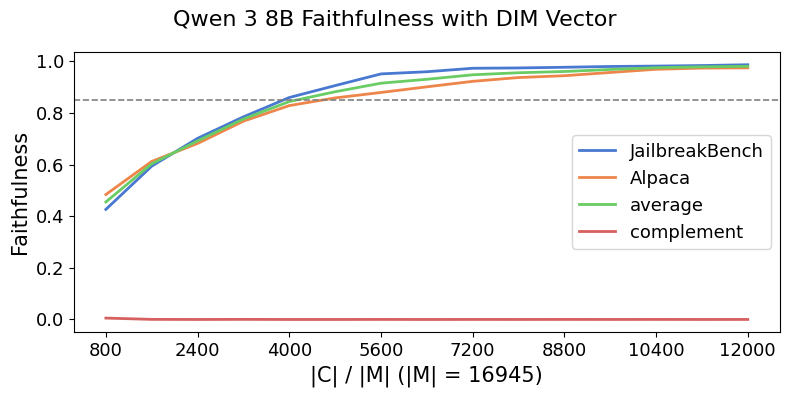

In [13]:
# paper ready graph: harmless and harmful g2
ns = [800, 1600, 2400, 3200, 4000, 4800, 5600, 6400, 7200, 8000, 8800, 9600, 10400, 11200, 12000]
q8_dim_logit = get_n_scores(
    q8_model_path,
    ns,
    'dim_logit'
)
invert_q8_dim_logit = get_n_scores(
    q8_model_path,
    ns,
    'dim_logit',
    invert=True
)
xticks=[800, 2400, 4000, 5600, 7200, 8800, 10400, 12000]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

print([i[0] for i in q8_dim_logit[0]])
print([i[0] for i in q8_dim_logit[1]])
print([i[0] for i in avg(q8_dim_logit)])
print([i[0] for i in avg(invert_q8_dim_logit)])

line_plot(
    [q8_dim_logit[0], q8_dim_logit[1], avg(q8_dim_logit), avg(invert_q8_dim_logit)], 
    ['JailbreakBench', 'Alpaca', 'average', 'complement'],
    "Qwen 3 8B Faithfulness with DIM Vector",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=16945
)

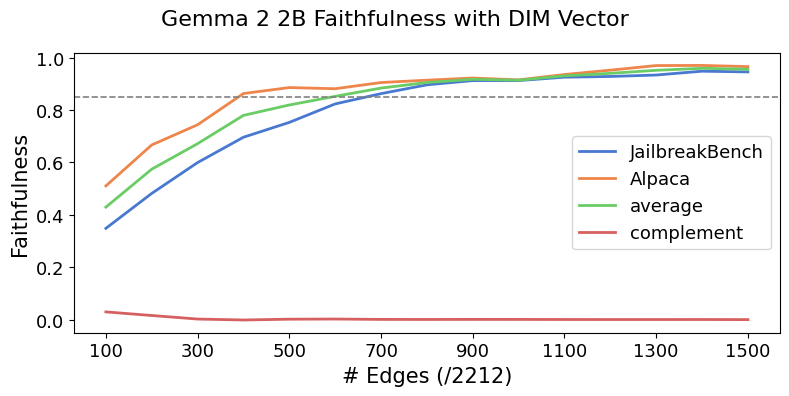

In [113]:
# paper ready graph: harmless and harmful g2
ns = [100,200,300,400,500,600,700,800,900,1000, 1100, 1200, 1300, 1400, 1500]
g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit'
)
invert_g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit',
    invert=True
)
xticks=[100, 300, 500, 700, 900, 1100, 1300, 1500]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)], 
    ['JailbreakBench', 'Alpaca', 'average', 'complement'],
    "Gemma 2 2B Faithfulness with DIM Vector",
    # "",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)

([(0.3845754029034114, 0.05140494976708358), (0.5748083524192709, 0.07509532487166329), (0.6806070601265045, 0.06864338413637217), (0.7837619385740221, 0.07623607181872813), (0.8526910436810178, 0.07006858322909634), (0.8925128063006531, 0.0557836150766125), (0.8954233391605592, 0.05073967232087157), (0.9264461986316547, 0.05334670811408009), (0.9534363550983351, 0.047307780955097675), (0.9507682614883369, 0.043725421845722576), (0.9674717528882425, 0.03900490004129403), (0.9769617192688443, 0.03540992377943412), (0.9840064351665113, 0.03433081584932794), (0.987007008266487, 0.028754748396227908), (0.9936560014827847, 0.025494939182269607)], [(0.3750224783117012, 0.09592806514955082), (0.5468050309871102, 0.10883161531565312), (0.6321537086645347, 0.10197025619885902), (0.6927974350917312, 0.10277919290612499), (0.723049416710876, 0.10171575726649254), (0.7536027810482938, 0.10303843405072981), (0.8010754345601595, 0.09639550952973176), (0.8231108000854145, 0.09206679762509415), (0.846

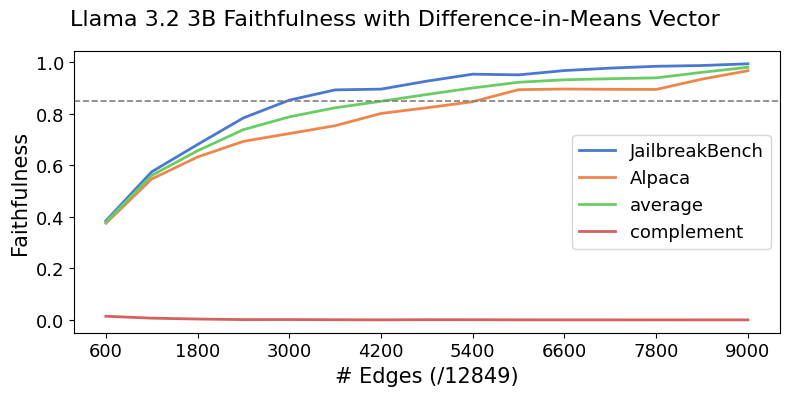

In [107]:
# paper ready graph: harmless and harmful l3
ns = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]
l3_dim_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns,
    'dim_logit'
)
invert_l3_dim_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns,
    'dim_logit',
    invert=True
)
print(l3_dim_logit)
xticks=[600,1800,3000,4200,5400,6600,7800,9000]
avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)], 
    ['JailbreakBench', 'Alpaca', 'average', 'complement'],
    # "",
    "Llama 3.2 3B Faithfulness with Difference-in-Means Vector",
    ns,
    0.85,
    colors=[None, None, None, None],
    num_edges=12849,
    xticks=xticks
)

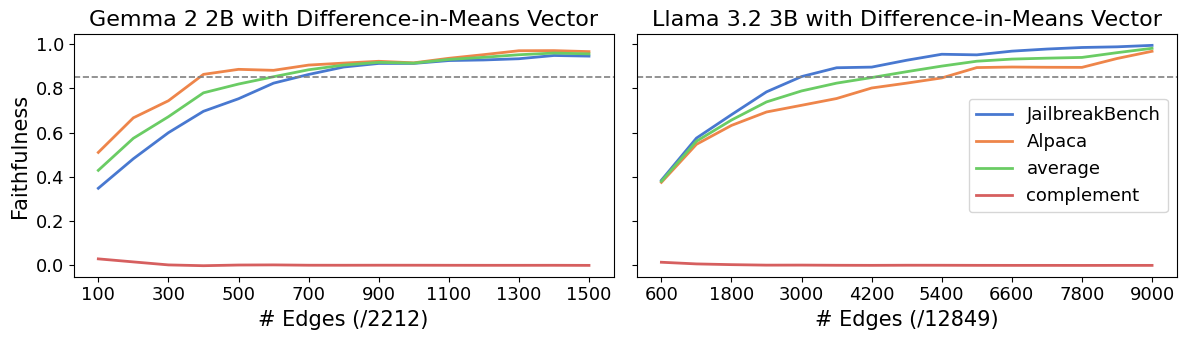

In [140]:
fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 4)

g2_xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
g2_xs = [100,200,300,400,500,600,700,800,900,1000, 1100, 1200, 1300, 1400, 1500]
l3_xticks = [600,1800,3000,4200,5400,6600,7800,9000]
l3_xs = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]

g2_data = [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)]
labels = ['JailbreakBench', 'Alpaca', 'average', 'complement']
for scores, label, p_color in zip(g2_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(g2_xs, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(g2_xticks)
axs[0].set_xticklabels(g2_xticks)
axs[0].set_xlabel(f'# Edges (/2212)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B with Difference-in-Means Vector", fontsize=16)

l3_data = [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)]
for scores, label, p_color in zip(l3_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(l3_xs, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(l3_xticks)
axs[1].set_xticklabels(l3_xticks, fontsize=13)
axs[1].set_xlabel(f'# Edges (/12849)', fontsize=15)
axs[1].set_title("Llama 3.2 3B with Difference-in-Means Vector", fontsize=16)


axs[1].legend(loc='right', fontsize=13)
plt.tight_layout()
plt.show()
sns.reset_defaults()



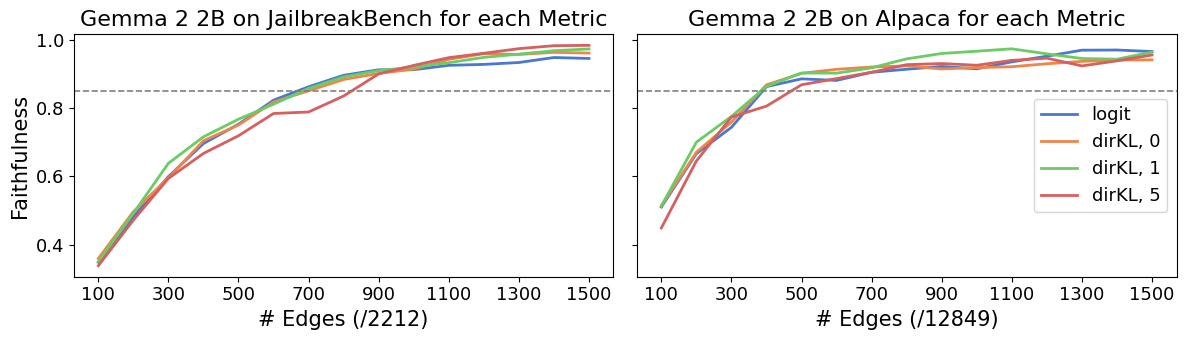

In [68]:
# based on metric
ns = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]
dim_logit_harm, dim_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_logit"
)
dim_dkl0_harm, dim_dkl0_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl0"
)
dim_dkl1_harm, dim_dkl1_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl1"
)
dim_dkl5_harm, dim_dkl5_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl5"
)

threshold = 0.85
# line_plot(
#     [dim_logit_harm, dim_dkl0_harm, dim_dkl1_harm, dim_dkl5_harm], 
#     ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5'],
#     "Gemma 2 2B Faithfulness on JailbreakBench for Different Metrics",
#     ns,
#     threshold
# )
# line_plot(
#     [dim_logit_safe, dim_dkl0_safe, dim_dkl1_safe, dim_dkl5_safe], 
#     ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5'],
#     "Gemma 2 2B Faithfulness on Alpaca for Different Metrics",
#     ns,
#     threshold
# )
xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 4)
jbb_data = [dim_logit_harm, dim_dkl0_harm, dim_dkl1_harm, dim_dkl5_harm]
labels = ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'# Edges (/2212)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B on JailbreakBench for each Metric", fontsize=16)

alpaca_data = [dim_logit_safe, dim_dkl0_safe, dim_dkl1_safe, dim_dkl5_safe]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'# Edges (/12849)', fontsize=15)
axs[1].set_title("Gemma 2 2B on Alpaca for each Metric", fontsize=16)

axs[1].legend(loc='right', fontsize=13)
plt.tight_layout()
plt.savefig('faith_metrics_g2.pdf')
plt.show()



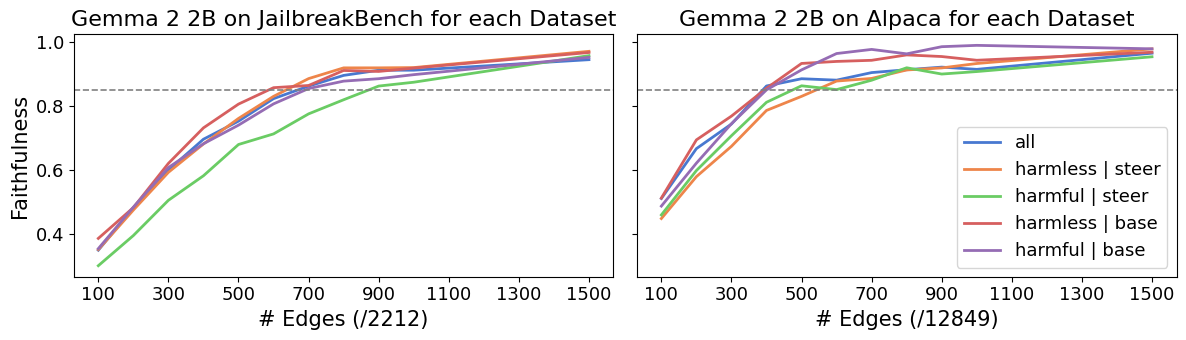

In [69]:
# vary datasets

ns = [100,200,300,400,500,600,700,800,900,1000,1500]
base_harmless = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_base_harmless"
)
base_harmful = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_base_harmful"
)
steer_harmless = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_steer_harmful"
)
steer_harmful = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_steer_harmless"
)
all = get_n_scores(
    'google/gemma-2-2b-it',
    ns=ns,
    exp_name = 'dim_logit'
)

threshold = 0.85

# line_plot(
#     [all[0], steer_harmless[0], steer_harmful[0], base_harmless[0], base_harmful[0]], 
#     ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
#     "Gemma 2 2B Faithfulness on JailbreakBench for Each Dataset",
#     ns,
#     threshold,
#     colors=['gray', None, None, None, None]
# )
# line_plot(
#     [all[1], steer_harmless[1], steer_harmful[1], base_harmless[1], base_harmful[1]], 
#     ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
#     "Gemma 2 2B Faithfulness on Alpaca for Each Dataset",
#     ns,
#     threshold,
#     colors=['gray', None, None, None, None]
# )

xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 5)
jbb_data = [all[0], steer_harmless[0], steer_harmful[0], base_harmless[0], base_harmful[0]]
labels = ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'# Edges (/2212)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B on JailbreakBench for each Dataset", fontsize=16)

alpaca_data = [all[1], steer_harmless[1], steer_harmful[1], base_harmless[1], base_harmful[1]]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'# Edges (/12849)', fontsize=15)
axs[1].set_title("Gemma 2 2B on Alpaca for each Dataset", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('faith_datasets_g2.pdf')
plt.show()



### Llama 3.2 3B faithfulness across all methods and faithfulness interchange

../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_600_simple_harmful_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_1200_simple_harmless_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_1200_simple_harmful_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_1800_simple_harmless_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_1800_simple_harmful_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_2400_simple_harmless_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_2400_simple_harmful_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_3000_simple_harmless_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_3000_simple_harmful_invert.json does not exist
../circuits/Llama-3.2-3B-Instruct/ntp_logit/faithfulness_3600

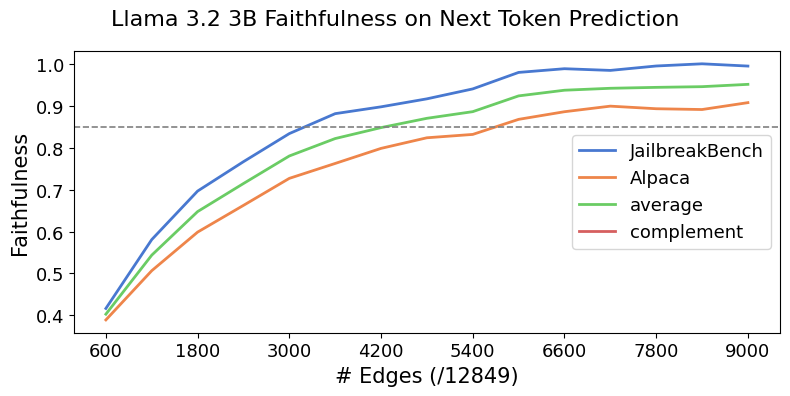

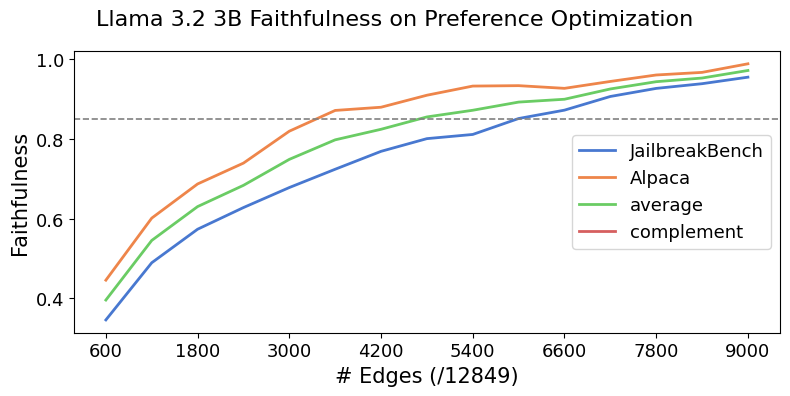

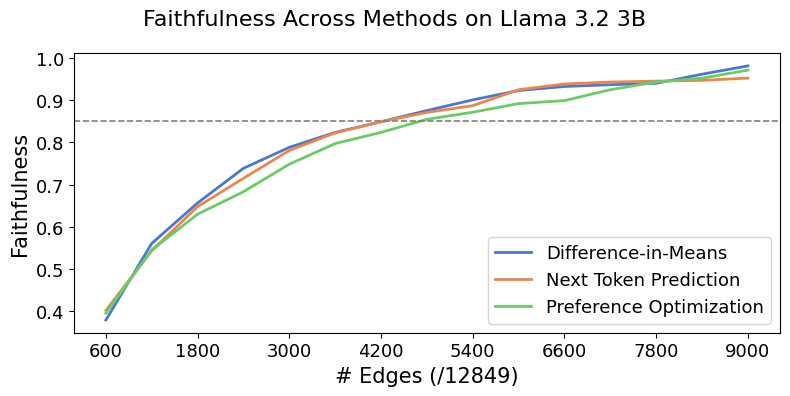

In [17]:
# Llama Faithfulness across all three methods

ns = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]

l3_model_path = 'meta-llama/Llama-3.2-3B-Instruct'
ntp_logit = get_n_scores(
    l3_model_path,
    ns,
    'ntp_logit'
)
reps_logit = get_n_scores(
    l3_model_path,
    ns,
    'reps_logit'
)
dim_logit = get_n_scores(
    l3_model_path,
    ns,
    'dim_logit'
)
invert_ntp_logit = get_n_scores(
    l3_model_path,
    ns,
    'ntp_logit',
    invert=True
)
invert_reps_logit = get_n_scores(
    l3_model_path,
    ns,
    'reps_logit',
    invert=True
)
invert_dim_logit = get_n_scores(
    l3_model_path,
    ns,
    'dim_logit',
    invert=True
)
xticks = [600,1800,3000,4200,5400,6600,7800,9000]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [ntp_logit[0], ntp_logit[1], avg(ntp_logit), avg(invert_ntp_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Llama 3.2 3B Faithfulness on Next Token Prediction",
    ns,
    0.85,
    colors=[None, None, None, None],
    num_edges=12849,
    xticks=xticks
)
line_plot(
    [reps_logit[0], reps_logit[1], avg(reps_logit), avg(invert_reps_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Llama 3.2 3B Faithfulness on Preference Optimization",
    ns,
    0.85,
    colors=[None, None, None, None],
    num_edges=12849,
    xticks=xticks
)
line_plot(
    [avg(dim_logit), avg(ntp_logit), avg(reps_logit)], 
    ['Difference-in-Means', 'Next Token Prediction', "Preference Optimization"],
    "Faithfulness Across Methods on Llama 3.2 3B",
    ns,
    0.85,
    colors=[None, None, None, None],
    num_edges=12849,
    xticks=xticks,
    legend_loc='lower right'
)


In [18]:
dim_ns = [4200]
ntp_ns = [4200]
reps_ns = [4800]
dim_on_ntp_scores = get_n_scores(l3_model_path, dim_ns,
    'ntp_logit/dim_on_ntp'
)
dim_on_reps_scores = get_n_scores(l3_model_path,
    dim_ns,
    'reps_logit/dim_on_reps'
)
dim_on_dim_scores = get_n_scores(l3_model_path,
    dim_ns,
    'dim_logit'
)
dim_on_rand_scores = get_n_scores(l3_model_path,
    dim_ns,
    'dim_logit',
    method='random'
)
ntp_on_ntp_scores = get_n_scores(l3_model_path, ntp_ns,
    'ntp_logit'
)
ntp_on_reps_scores = get_n_scores(l3_model_path,
    ntp_ns,
    'reps_logit/ntp_on_reps'
)
ntp_on_dim_scores = get_n_scores(l3_model_path,
    ntp_ns,
    'dim_logit/ntp_on_dim'
)
ntp_on_rand_scores = get_n_scores(l3_model_path,
    ntp_ns,
    'ntp_logit',
    method='random'
)
reps_on_ntp_scores = get_n_scores(l3_model_path, reps_ns,
    'ntp_logit/reps_on_ntp'
)
reps_on_reps_scores = get_n_scores(l3_model_path,
    reps_ns,
    'reps_logit'
)
reps_on_dim_scores = get_n_scores(l3_model_path,
    reps_ns,
    'dim_logit/reps_on_dim'
)
reps_on_rand_scores = get_n_scores(l3_model_path,
    reps_ns,
    'reps_logit',
    method='random'
)

def avg(scores):
    harmful, harmless = scores
    return (harmful[0][0] + harmless[0][0]) / 2


vector_labels = ['DIM', 'NTP', 'PO']
circuit_labels = ['DIM', 'NTP', 'PO', 'random']


{'DIM': [0.8482493868603593, 0.814366775385032, 0.7168492669580602, 0.03624013468942837], 'NTP': [0.8526548305312422, 0.848198800465734, 0.7841329008419582, 0.03216792381698519], 'PO': [0.8767072249869906, 0.8554326768265047, 0.854052076029613, 0.05996868388228577]}


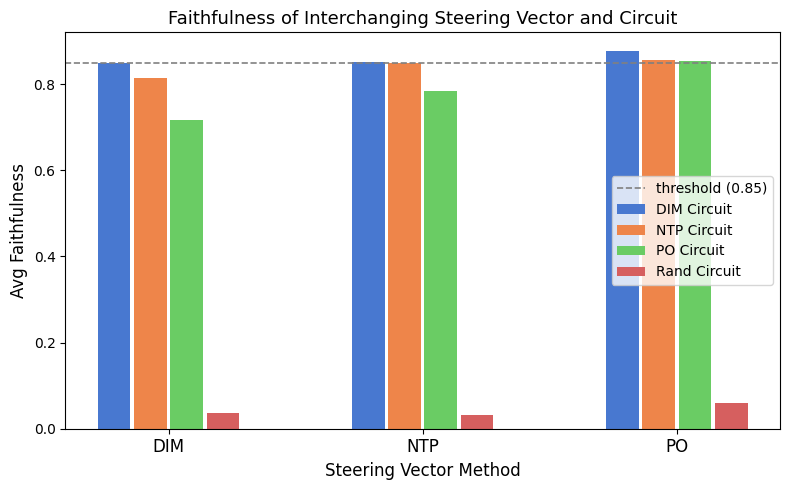

In [19]:
data = {
    'DIM':  [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),
    avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP':  [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),
    avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':   [avg(reps_on_dim_scores), avg(reps_on_ntp_scores),
   avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
print(data)

circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Rand Circuit']
steer_methods  = list(data.keys())
n_groups  = len(steer_methods)
n_bars    = len(circuit_labels)

x = np.arange(n_groups)*0.7
bar_width = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

palette = sns.color_palette("muted", n_bars)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, color) in enumerate(zip(circuit_labels, palette)):
    heights = [data[m][i] for m in steer_methods]
    ax.bar(x + offsets[i], heights, width=bar_width*0.9, label=label, color=color)

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2, label='threshold (0.85)')
ax.set_xticks(x)
ax.set_xticklabels(steer_methods, fontsize=12)
ax.set_ylabel('Avg Faithfulness', fontsize=12)
ax.set_xlabel('Steering Vector Method', fontsize=12)
ax.set_title('Faithfulness of Interchanging Steering Vector and Circuit', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3037811/252135111.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)


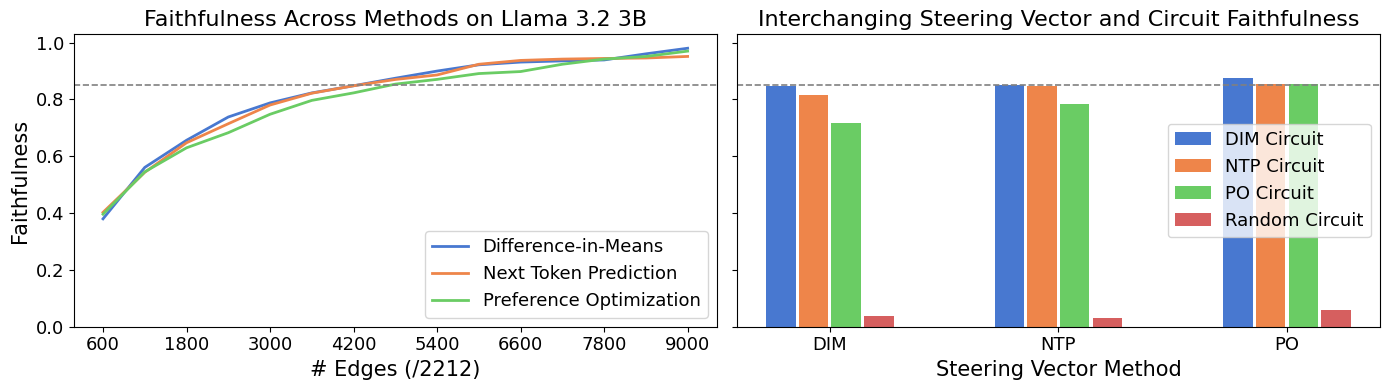

In [20]:
# Combined figure: "Faithfulness Across Methods" (line) + "Interchanging Steering Vector and Circuit" (bar)
ns_line = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]
avg_list = lambda x: [((a[0]+b[0])/2, -1) for a, b in zip(x[0], x[1])]

line_data   = [avg_list(dim_logit), avg_list(ntp_logit), avg_list(reps_logit)]
line_labels = ['Difference-in-Means', 'Next Token Prediction', 'Preference Optimization']

bar_data = {
    'DIM': [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),  avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP': [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),  avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':  [avg(reps_on_dim_scores), avg(reps_on_ntp_scores), avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
bar_circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Random Circuit']
steer_methods = list(bar_data.keys())

palette = sns.color_palette("muted", 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left: line plot ---
for scores, label, color in zip(line_data, line_labels, palette[:3]):
    means = np.array([s[0] for s in scores])
    ax1.plot(ns_line, means, marker=None, label=label, linewidth=2, color=color)
ax1.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax1.set_xticks([600,1800,3000,4200,5400,6600,7800,9000])
ax1.set_xticklabels([600,1800,3000,4200,5400,6600,7800,9000], fontsize=13)
ax1.set_xlabel('# Edges (/2212)', fontsize=15)
ax1.set_ylabel('Faithfulness', fontsize=15)
ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)
ax1.set_title('Faithfulness Across Methods on Llama 3.2 3B', fontsize=16)
ax1.legend(fontsize=13, loc='lower right')

# --- Right: grouped bar plot ---
x = np.arange(len(steer_methods)) * 0.7
bar_width = 0.10
offsets = np.linspace(-(len(bar_circuit_labels)-1)/2, (len(bar_circuit_labels)-1)/2, len(bar_circuit_labels)) * bar_width

for i, (label, color) in enumerate(zip(bar_circuit_labels, palette)):
    heights = [bar_data[m][i] for m in steer_methods]
    ax2.bar(x + offsets[i], heights, width=bar_width * 0.9, label=label, color=color)

ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(steer_methods, fontsize=13)
ax2.set_xlabel('Steering Vector Method', fontsize=15)
ax2.set_title('Interchanging Steering Vector and Circuit Faithfulness', fontsize=16)
ax2.legend(fontsize=13, loc='right')

plt.tight_layout()
plt.savefig("faith_methods_combined_l3.pdf", bbox_inches='tight')
plt.show()


create plot for circuit faithfulness interchange on Gemma 2 2B

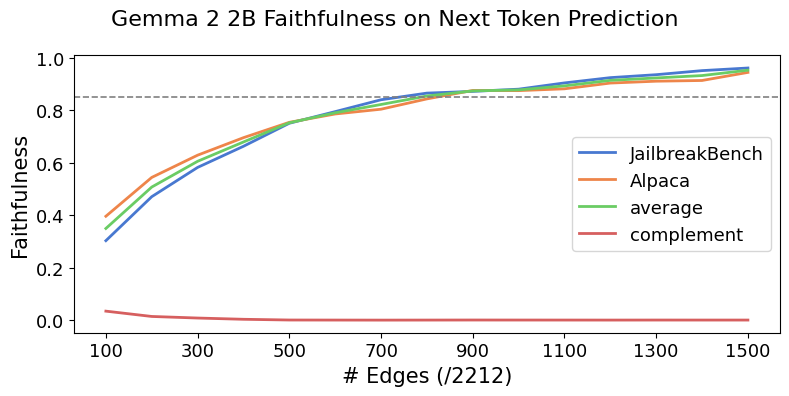

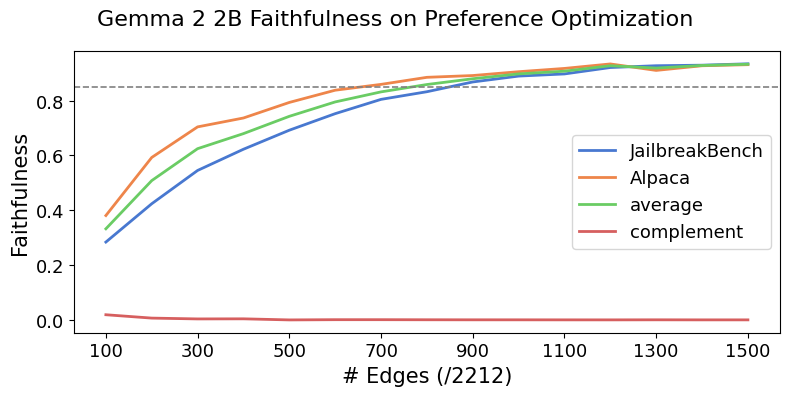

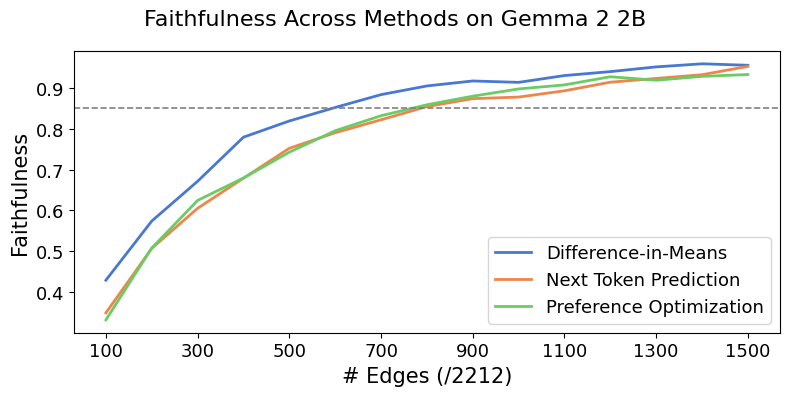

In [10]:
# paper ready graph: harmful and harmless g2 ntp
# ns = [100,200,300,400,500,600,700,800,900,1000,1500]
ns = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]

ntp_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'ntp_logit'
)
reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'reps_logit'
)
dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit'
)
invert_ntp_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'ntp_logit',
    invert=True
)
invert_reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'reps_logit',
    invert=True
)
invert_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit',
    invert=True
)
xticks =[100,300,500,700,900,1100,1300,1500]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [ntp_logit[0], ntp_logit[1], avg(ntp_logit), avg(invert_ntp_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Next Token Prediction",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)
line_plot(
    [reps_logit[0], reps_logit[1], avg(reps_logit), avg(invert_reps_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Preference Optimization",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)
line_plot(
    [avg(dim_logit), avg(ntp_logit), avg(reps_logit)], 
    ['Difference-in-Means', 'Next Token Prediction', "Preference Optimization"],
    "Faithfulness Across Methods on Gemma 2 2B",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    legend_loc='lower right'
)


In [13]:
dim_ns = [600]
ntp_ns = [800]
reps_ns = [800]
model_path = 'google/gemma-2-2b-it'
dim_on_ntp_scores = get_n_scores(model_path, dim_ns,
    'ntp_logit/dim_on_ntp'
)
dim_on_reps_scores = get_n_scores(model_path,
    dim_ns,
    'reps_logit/dim'
)
dim_on_dim_scores = get_n_scores(model_path,
    dim_ns,
    'dim_logit'
)
dim_on_rand_scores = get_n_scores(model_path,
    dim_ns,
    'dim_logit',
    method='random'
)
ntp_on_ntp_scores = get_n_scores(model_path, ntp_ns,
    'ntp_logit'
)
ntp_on_reps_scores = get_n_scores(model_path,
    ntp_ns,
    'reps_logit/ntp_on_reps'
)
ntp_on_dim_scores = get_n_scores(model_path,
    ntp_ns,
    'dim_logit/ntp_on_dim'
)
ntp_on_rand_scores = get_n_scores(model_path,
    ntp_ns,
    'ntp_logit',
    method='random'
)
reps_on_ntp_scores = get_n_scores(model_path, reps_ns,
    'ntp_logit/reps_on_ntp'
)
reps_on_reps_scores = get_n_scores(model_path,
    reps_ns,
    'reps_logit'
)
reps_on_dim_scores = get_n_scores(model_path,
    reps_ns,
    'dim_logit/reps_on_dim'
)
reps_on_rand_scores = get_n_scores(model_path,
    reps_ns,
    'reps_logit',
    method='random'
)

def avg(scores):
    harmful, harmless = scores
    return (harmful[0][0] + harmless[0][0]) / 2


vector_labels = ['DIM', 'NTP', 'PO']
circuit_labels = ['DIM', 'NTP', 'PO', 'random']


{'DIM': [0.8519499927667813, 0.8389070874264188, 0.8045153266383157, 0.07110935686601542], 'NTP': [0.8255328178991664, 0.8541710733068173, 0.8160371543745442, 0.1463672460028112], 'PO': [0.8879876221250621, 0.8450508564777717, 0.8585878969034866, 0.19476202869929937]}


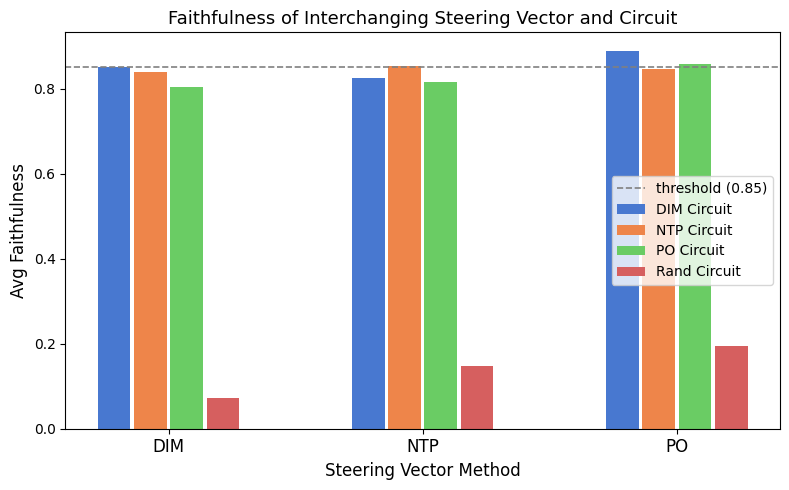

In [15]:
data = {
    'DIM':  [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),
    avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP':  [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),
    avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':   [avg(reps_on_dim_scores), avg(reps_on_ntp_scores),
   avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
print(data)

circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Rand Circuit']
steer_methods  = list(data.keys())
n_groups  = len(steer_methods)
n_bars    = len(circuit_labels)

x = np.arange(n_groups)*0.7
bar_width = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

palette = sns.color_palette("muted", n_bars)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, color) in enumerate(zip(circuit_labels, palette)):
    heights = [data[m][i] for m in steer_methods]
    ax.bar(x + offsets[i], heights, width=bar_width*0.9, label=label, color=color)

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2, label='threshold (0.85)')
ax.set_xticks(x)
ax.set_xticklabels(steer_methods, fontsize=12)
ax.set_ylabel('Avg Faithfulness', fontsize=12)
ax.set_xlabel('Steering Vector Method', fontsize=12)
ax.set_title('Faithfulness of Interchanging Steering Vector and Circuit', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3037811/2642729583.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)


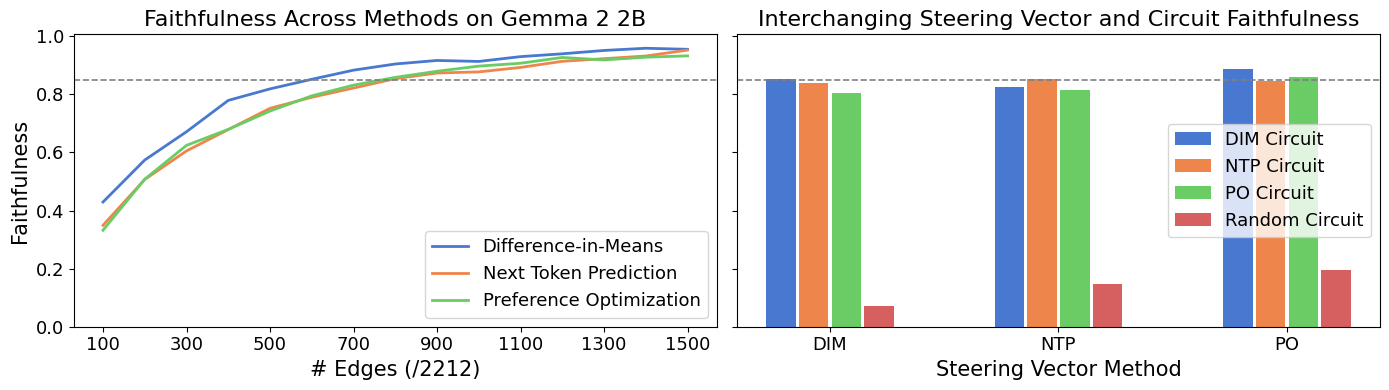

In [16]:
# Combined figure: "Faithfulness Across Methods" (line) + "Interchanging Steering Vector and Circuit" (bar)
ns_line = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]
avg_list = lambda x: [((a[0]+b[0])/2, -1) for a, b in zip(x[0], x[1])]

line_data   = [avg_list(dim_logit), avg_list(ntp_logit), avg_list(reps_logit)]
line_labels = ['Difference-in-Means', 'Next Token Prediction', 'Preference Optimization']

bar_data = {
    'DIM': [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),  avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP': [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),  avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':  [avg(reps_on_dim_scores), avg(reps_on_ntp_scores), avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
bar_circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Random Circuit']
steer_methods = list(bar_data.keys())

palette = sns.color_palette("muted", 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left: line plot ---
for scores, label, color in zip(line_data, line_labels, palette[:3]):
    means = np.array([s[0] for s in scores])
    ax1.plot(ns_line, means, marker=None, label=label, linewidth=2, color=color)
ax1.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax1.set_xticks([100,300,500,700,900,1100,1300,1500])
ax1.set_xticklabels([100,300,500,700,900,1100,1300,1500], fontsize=13)
ax1.set_xlabel('# Edges (/2212)', fontsize=15)
ax1.set_ylabel('Faithfulness', fontsize=15)
ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)
ax1.set_title('Faithfulness Across Methods on Gemma 2 2B', fontsize=16)
ax1.legend(fontsize=13, loc='lower right')

# --- Right: grouped bar plot ---
x = np.arange(len(steer_methods)) * 0.7
bar_width = 0.10
offsets = np.linspace(-(len(bar_circuit_labels)-1)/2, (len(bar_circuit_labels)-1)/2, len(bar_circuit_labels)) * bar_width

for i, (label, color) in enumerate(zip(bar_circuit_labels, palette)):
    heights = [bar_data[m][i] for m in steer_methods]
    ax2.bar(x + offsets[i], heights, width=bar_width * 0.9, label=label, color=color)

ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(steer_methods, fontsize=13)
ax2.set_xlabel('Steering Vector Method', fontsize=15)
ax2.set_title('Interchanging Steering Vector and Circuit Faithfulness', fontsize=16)
ax2.legend(fontsize=13, loc='right')

plt.tight_layout()
plt.savefig("faith_methods_combined_g2.pdf", bbox_inches='tight')
plt.show()


llama 3.2 3B faithfulness on individual patching datasets

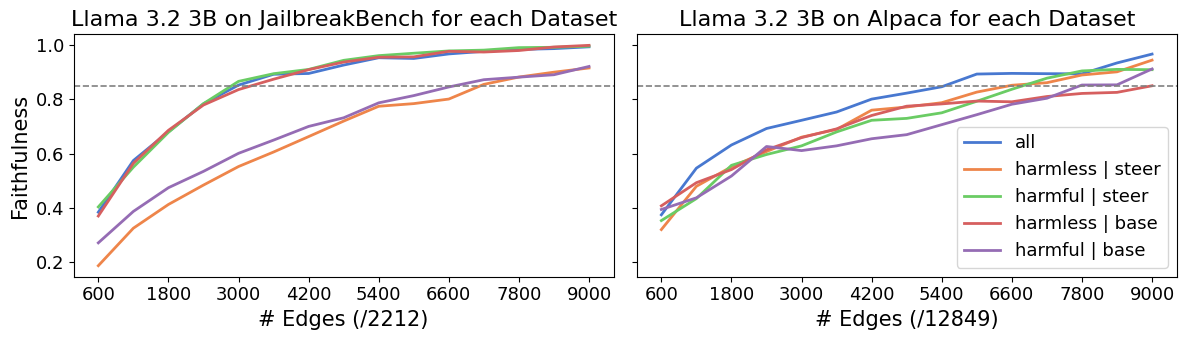

In [ ]:
# paper ready graph
ns = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]
all_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "dim_logit"
)
logit_steer_harmless = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_steer_harmless"
)
logit_steer_harmful = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_steer_harmful"
)
logit_base_harmless = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_base_harmless"
)
logit_base_harmful = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_base_harmful"
)

xticks = [600,1800,3000,4200,5400,6600,7800,9000]


fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 5)
jbb_data = [all_logit[0], logit_steer_harmless[0], logit_steer_harmful[0], logit_base_harmless[0], logit_base_harmful[0]]
labels = ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'# Edges (/2212)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Llama 3.2 3B on JailbreakBench for each Dataset", fontsize=16)

alpaca_data = [all_logit[1], logit_steer_harmless[1], logit_steer_harmful[1], logit_base_harmless[1], logit_base_harmful[1]]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(ns, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'# Edges (/12849)', fontsize=15)
axs[1].set_title("Llama 3.2 3B on Alpaca for each Dataset", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('faith_datasets_l3.pdf')
plt.show()


# granular faithfulness

In [6]:
num_edges_g2 = 8790
num_edges_l3 = 124441
num_edges_q8 = 195865

### Gemma

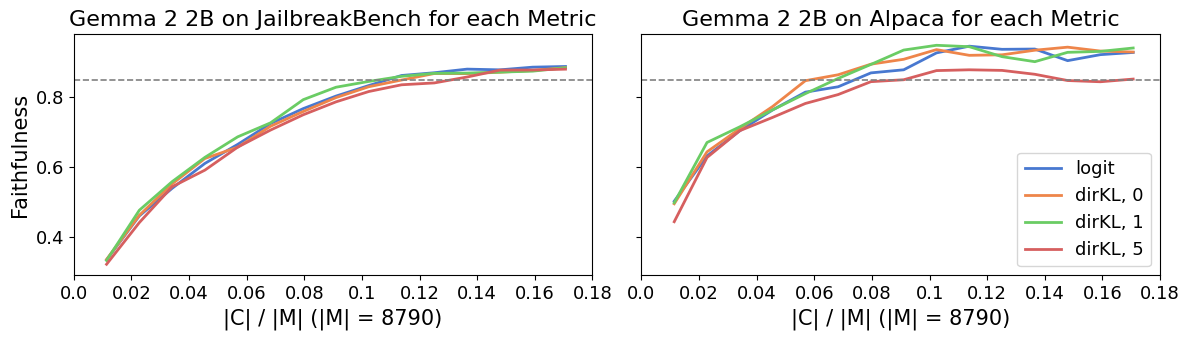

In [36]:
# based on metric
ns_g2 = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]
g2_model_path = 'google/gemma-2-2b-it'
ig2_dim_logit_harm, ig2_dim_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns_g2,
    exp_name = "ig2_dim_logit"
)
ig2_dim_dkl0_harm, ig2_dim_dkl0_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns_g2,
    exp_name = "ig2_dim_dkl0"
)
ig2_dim_dkl1_harm, ig2_dim_dkl1_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns_g2,
    exp_name = "ig2_dim_dkl1"
)
ig2_dim_dkl5_harm, ig2_dim_dkl5_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns_g2,
    exp_name = "ig2_dim_dkl5"
)
xs_g2 = [n / num_edges_g2 for n in ns_g2]

# xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]

threshold = 0.85

fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 4)
jbb_data = [ig2_dim_logit_harm, ig2_dim_dkl0_harm, ig2_dim_dkl1_harm, ig2_dim_dkl5_harm]
labels = ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(xs_g2, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'|C| / |M| (|M| = 8790)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B on JailbreakBench for each Metric", fontsize=16)

alpaca_data = [ig2_dim_logit_safe, ig2_dim_dkl0_safe, ig2_dim_dkl1_safe, ig2_dim_dkl5_safe]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(xs_g2, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'|C| / |M| (|M| = 8790)', fontsize=15)
axs[1].set_title("Gemma 2 2B on Alpaca for each Metric", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('granular/faith_metrics_g2.pdf')
plt.show()



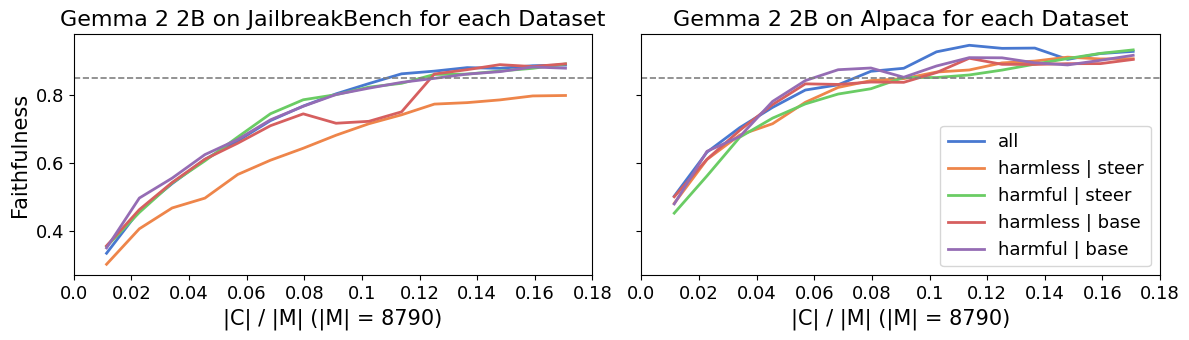

In [56]:
# paper ready graph
all_logit = get_n_scores(
    g2_model_path,
    ns = ns_g2,
    exp_name = "ig2_dim_logit"
)
logit_steer_harmless = get_n_scores(
    g2_model_path,
    ns = ns_g2,
    exp_name = "ig2_dim_logit_steer_harmless"
)
logit_steer_harmful = get_n_scores(
    g2_model_path,
    ns = ns_g2,
    exp_name = "ig2_dim_logit_steer_harmful"
)
logit_base_harmless = get_n_scores(
    g2_model_path,
    ns = ns_g2,
    exp_name = "ig2_dim_logit_base_harmless"
)
logit_base_harmful = get_n_scores(
    g2_model_path,
    ns = ns_g2,
    exp_name = "ig2_dim_logit_base_harmful"
)

xs_g2 = [n / num_edges_g2 for n in ns_g2]

# xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]

fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 5)
jbb_data = [all_logit[0], logit_steer_harmless[0], logit_steer_harmful[0], logit_base_harmless[0], logit_base_harmful[0]]
labels = ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(xs_g2, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'|C| / |M| (|M| = 8790)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B on JailbreakBench for each Dataset", fontsize=16)

alpaca_data = [all_logit[1], logit_steer_harmless[1], logit_steer_harmful[1], logit_base_harmless[1], logit_base_harmful[1]]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(xs_g2, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'|C| / |M| (|M| = 8790)', fontsize=15)
axs[1].set_title("Gemma 2 2B on Alpaca for each Dataset", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('granular/faith_datasets_g2.pdf')
plt.show()


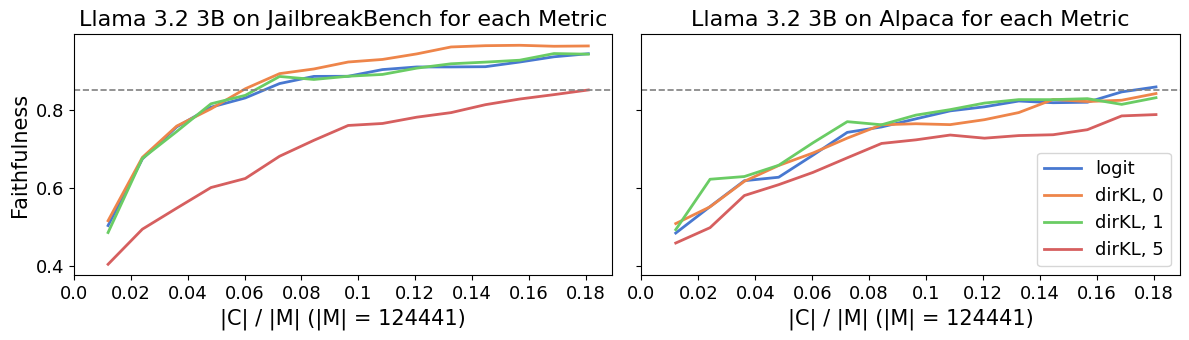

In [43]:
# based on metric
ns_l3 = [1500,3000,4500,6000,7500,9000,10500,12000,13500,15000,16500,18000,19500,21000,22500]
ig2_dim_logit_harm, ig2_dim_logit_safe = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit"
)
ig2_dim_dkl0_harm, ig2_dim_dkl0_safe = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_dkl0"
)
ig2_dim_dkl1_harm, ig2_dim_dkl1_safe = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_dkl1"
)
ig2_dim_dkl5_harm, ig2_dim_dkl5_safe = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_dkl5"
)
xs_l3 = [n / num_edges_l3 for n in ns_l3]

# xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]

threshold = 0.85

fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 4)
jbb_data = [ig2_dim_logit_harm, ig2_dim_dkl0_harm, ig2_dim_dkl1_harm, ig2_dim_dkl5_harm]
labels = ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(xs_l3, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'|C| / |M| (|M| = {num_edges_l3})', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Llama 3.2 3B on JailbreakBench for each Metric", fontsize=16)

alpaca_data = [ig2_dim_logit_safe, ig2_dim_dkl0_safe, ig2_dim_dkl1_safe, ig2_dim_dkl5_safe]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(xs_l3, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'|C| / |M| (|M| = {num_edges_l3})', fontsize=15)
axs[1].set_title("Llama 3.2 3B on Alpaca for each Metric", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('granular/faith_metrics_l3.pdf')
plt.show()



[0.48468508 0.55244484 0.61884561 0.62769834 0.6842258  0.74267559
 0.75658379 0.77736302 0.79776698 0.80816589 0.82302778 0.81868486
 0.81992027 0.84639614 0.85914483] [0.012053905063443721, 0.024107810126887442, 0.03616171519033116, 0.048215620253774884, 0.0602695253172186, 0.07232343038066232, 0.08437733544410604, 0.09643124050754977, 0.10848514557099348, 0.1205390506344372, 0.13259295569788093, 0.14464686076132463, 0.15670076582476836, 0.16875467088821208, 0.1808085759516558]


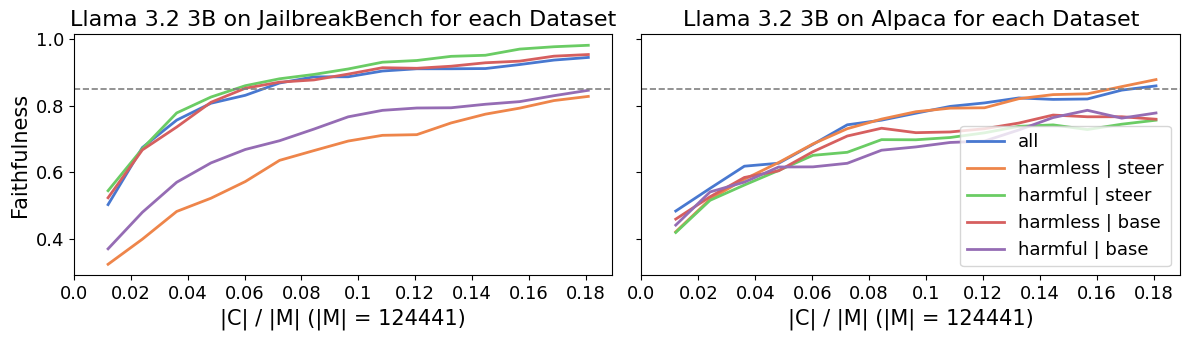

In [57]:
# paper ready graph
all_logit = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit"
)
logit_steer_harmless = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit_steer_harmless"
)
logit_steer_harmful = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit_steer_harmful"
)
logit_base_harmless = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit_base_harmless"
)
logit_base_harmful = get_n_scores(
    l3_model_path,
    ns = ns_l3,
    exp_name = "ig2_dim_logit_base_harmful"
)

xs_l3 = [n / num_edges_l3 for n in ns_l3]

# xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]

fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 5)
jbb_data = [all_logit[0], logit_steer_harmless[0], logit_steer_harmful[0], logit_base_harmless[0], logit_base_harmful[0]]
labels = ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base']
for scores, label, p_color in zip(jbb_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(xs_l3, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel(f'|C| / |M| (|M| = 124441)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Llama 3.2 3B on JailbreakBench for each Dataset", fontsize=16)

alpaca_data = [all_logit[1], logit_steer_harmless[1], logit_steer_harmful[1], logit_base_harmless[1], logit_base_harmful[1]]
for scores, label, p_color in zip(alpaca_data, labels, palette):
    means = np.array([s[0] for s in scores])
    if label=='all': print(means, xs_l3)
    stds = np.array([s[1] for s in scores])
    axs[1].plot(xs_l3, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=13)
axs[1].set_xlabel(f'|C| / |M| (|M| = 124441)', fontsize=15)
axs[1].set_title("Llama 3.2 3B on Alpaca for each Dataset", fontsize=16)

axs[1].legend(loc='lower right', fontsize=13)
plt.tight_layout()
plt.savefig('granular/faith_datasets_l3.pdf')
plt.show()


[(0.41812789666489875, -1), (0.5459122822934739, -1), (0.6214598608372643, -1), (0.6869509793250211, -1), (0.7397346352683241, -1), (0.7772527091624675, -1), (0.8185986534188694, -1), (0.8409940568606489, -1), (0.8803135326427818, -1), (0.9043327347756132, -1), (0.9037550081171125, -1), (0.9093303282273323, -1), (0.89166581905548, -1), (0.9041043166036479, -1), (0.9082401755659809, -1)]
saving to granular/faith_g2_dim.pdf


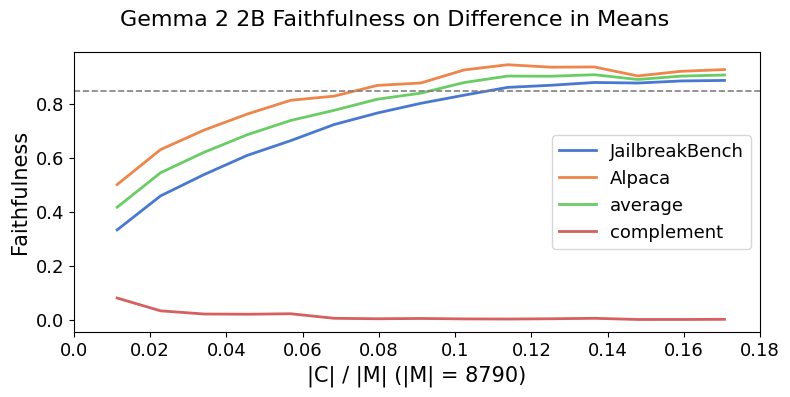

saving to granular/faith_g2_ntp.pdf


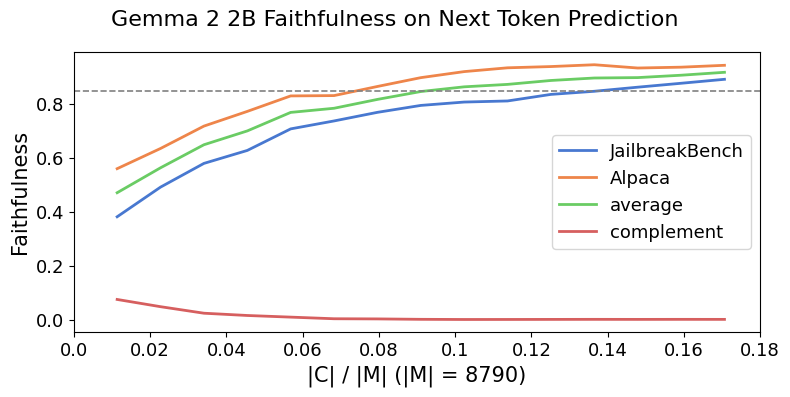

saving to granular/faith_g2_po.pdf


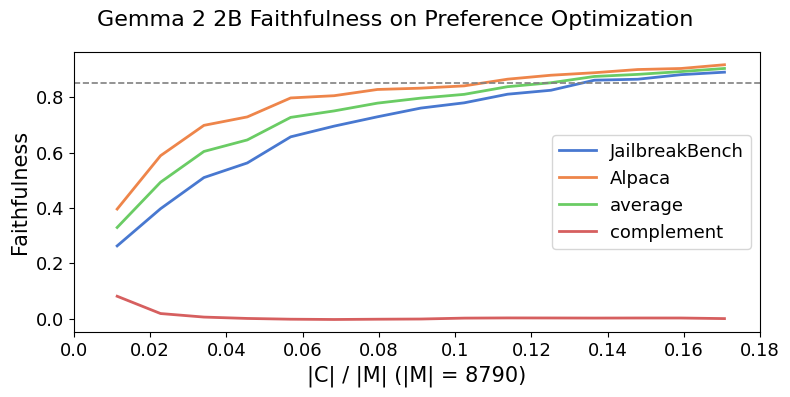

saving to granular/faith_g2.pdf


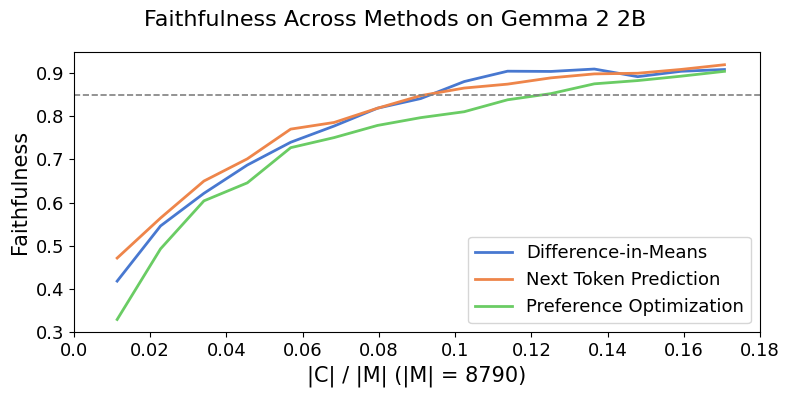

In [26]:
# paper ready graph: harmful and harmless g2 ntp
ns_g2 = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]

ntp_logit = get_n_scores(
    g2_model_path,
    ns_g2,
    'ig2_ntp_logit'
)
reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns_g2,
    'ig2_reps_logit'
)
g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns_g2,
    'ig2_dim_logit'
)
invert_ntp_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns_g2,
    'ig2_ntp_logit',
    invert=True
)
invert_reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns_g2,
    'ig2_reps_logit',
    invert=True
)
invert_g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns_g2,
    'ig2_dim_logit',
    invert=True
)
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
# xticks = [100,300,500,700,900,1100,1300,1500]

g2_xs = [n / num_edges_g2 for n in ns_g2]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]
print(avg(g2_dim_logit))
line_plot(
    [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Difference in Means",
    g2_xs,
    # ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_g2,
    save_name='granular/faith_g2_dim.pdf'
)
line_plot(
    [ntp_logit[0], ntp_logit[1], avg(ntp_logit), avg(invert_ntp_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Next Token Prediction",
    g2_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_g2,
    save_name='granular/faith_g2_ntp.pdf'
)
line_plot(
    [reps_logit[0], reps_logit[1], avg(reps_logit), avg(invert_reps_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Preference Optimization",
    g2_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_g2,
    save_name='granular/faith_g2_po.pdf'
)
line_plot(
    [avg(g2_dim_logit), avg(ntp_logit), avg(reps_logit)], 
    ['Difference-in-Means', 'Next Token Prediction', "Preference Optimization"],
    "Faithfulness Across Methods on Gemma 2 2B",
    g2_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_g2,
    legend_loc='lower right',
    save_name='granular/faith_g2.pdf'
)


In [27]:
dim_ns = [900]
ntp_ns = [900]
reps_ns = [1100]
model_path = 'google/gemma-2-2b-it'
dim_on_ntp_scores = get_n_scores(model_path, dim_ns,
    'ig2_ntp_logit/dim_on_ntp'
)
dim_on_reps_scores = get_n_scores(model_path,
    dim_ns,
    'ig2_reps_logit/dim_on_reps'
)
dim_on_dim_scores = get_n_scores(model_path,
    dim_ns,
    'ig2_dim_logit'
)
dim_on_rand_scores = get_n_scores(model_path,
    [2*n for n in dim_ns],
    'ig2_dim_logit',
    method='random'
)
ntp_on_ntp_scores = get_n_scores(model_path, ntp_ns,
    'ig2_ntp_logit'
)
ntp_on_reps_scores = get_n_scores(model_path,
    ntp_ns,
    'ig2_reps_logit/ntp_on_reps'
)
ntp_on_dim_scores = get_n_scores(model_path,
    ntp_ns,
    'ig2_dim_logit/ntp_on_dim'
)
ntp_on_rand_scores = get_n_scores(model_path,
    [2*n for n in ntp_ns],
    'ig2_ntp_logit',
    method='random'
)
reps_on_ntp_scores = get_n_scores(model_path, reps_ns,
    'ig2_ntp_logit/reps_on_ntp'
)
reps_on_reps_scores = get_n_scores(model_path,
    reps_ns,
    'ig2_reps_logit'
)
reps_on_dim_scores = get_n_scores(model_path,
    reps_ns,
    'ig2_dim_logit/reps_on_dim'
)
reps_on_rand_scores = get_n_scores(model_path,
    [2*n for n in reps_ns],
    'ig2_reps_logit',
    method='random'
)

def avg(scores):
    harmful, harmless = scores
    return (harmful[0][0] + harmless[0][0]) / 2


vector_labels = ['DIM', 'NTP', 'PO']
circuit_labels = ['DIM', 'NTP', 'PO', 'random']


{'DIM': [0.8803135326427818, 0.8652764938635553, 0.8104435609974335, 0.014408643673156842], 'NTP': [0.7496379390057999, 0.8652764938635553, 0.7324080566196323, 0.024118736411588813], 'PO': [0.8480715172832445, 0.8560380753921151, 0.852395573438101, 0.07957671571296521]}
[0.8803135326427818, 0.7496379390057999, 0.8480715172832445]
[0.8652764938635553, 0.8652764938635553, 0.8560380753921151]
[0.8104435609974335, 0.7324080566196323, 0.852395573438101]
[0.014408643673156842, 0.024118736411588813, 0.07957671571296521]


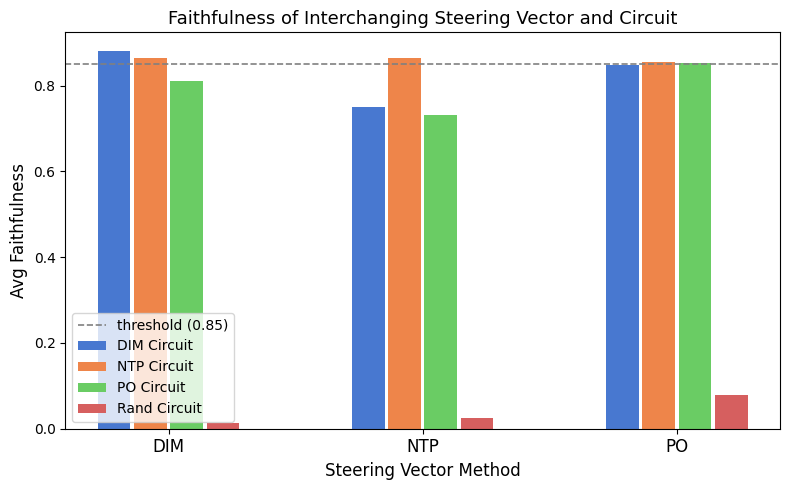

In [28]:
data = {
    'DIM':  [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),
    avg(dim_on_reps_scores),  max(avg(dim_on_rand_scores),0)],
    'NTP':  [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),
    avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':   [avg(reps_on_dim_scores), avg(reps_on_ntp_scores),
   avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
print(data)

circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Rand Circuit']
steer_methods  = list(data.keys())
n_groups  = len(steer_methods)
n_bars    = len(circuit_labels)

x = np.arange(n_groups)*0.7
bar_width = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

palette = sns.color_palette("muted", n_bars)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, color) in enumerate(zip(circuit_labels, palette)):
    heights = [data[m][i] for m in steer_methods]
    print(heights)
    ax.bar(x + offsets[i], heights, width=bar_width*0.9, label=label, color=color)

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2, label='threshold (0.85)')
ax.set_xticks(x)
ax.set_xticklabels(steer_methods, fontsize=12)
ax.set_ylabel('Avg Faithfulness', fontsize=12)
ax.set_xlabel('Steering Vector Method', fontsize=12)
ax.set_title('Faithfulness of Interchanging Steering Vector and Circuit', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

[0.8803135326427818, 0.7496379390057999, 0.8480715172832445]
[0.8652764938635553, 0.8652764938635553, 0.8560380753921151]
[0.8104435609974335, 0.7324080566196323, 0.852395573438101]
[0.014408643673156842, 0.024118736411588813, 0.07957671571296521]


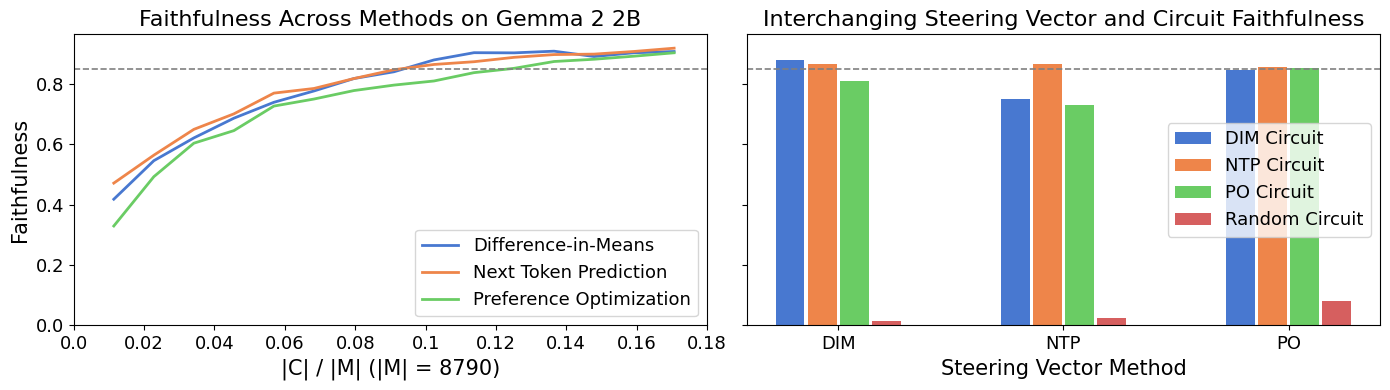

In [34]:
# Combined figure: "Faithfulness Across Methods" (line) + "Interchanging Steering Vector and Circuit" (bar)
ns_line = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]
avg_list = lambda x: [((a[0]+b[0])/2, -1) for a, b in zip(x[0], x[1])]

line_data   = [avg_list(g2_dim_logit), avg_list(ntp_logit), avg_list(reps_logit)]
line_labels = ['Difference-in-Means', 'Next Token Prediction', 'Preference Optimization']

bar_data = {
    'DIM': [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),  avg(dim_on_reps_scores),  max(0,avg(dim_on_rand_scores))],
    'NTP': [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),  avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':  [avg(reps_on_dim_scores), avg(reps_on_ntp_scores), avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
bar_circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Random Circuit']
steer_methods = list(bar_data.keys())

palette = sns.color_palette("muted", 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left: line plot ---
g2_xs = [n / num_edges_g2 for n in ns_line]
for scores, label, color in zip(line_data, line_labels, palette[:3]):
    means = np.array([s[0] for s in scores])
    ax1.plot(g2_xs, means, marker=None, label=label, linewidth=2, color=color)
ax1.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)

xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=13)
ax1.set_xlabel(f'|C| / |M| (|M| = {num_edges_g2})', fontsize=15)
ax1.set_ylabel('Faithfulness', fontsize=15)
ax1.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)
ax1.set_title('Faithfulness Across Methods on Gemma 2 2B', fontsize=16)
ax1.legend(fontsize=13, loc='lower right')

# --- Right: grouped bar plot ---
x = np.arange(len(steer_methods)) * 0.7
bar_width = 0.10
offsets = np.linspace(-(len(bar_circuit_labels)-1)/2, (len(bar_circuit_labels)-1)/2, len(bar_circuit_labels)) * bar_width

for i, (label, color) in enumerate(zip(bar_circuit_labels, palette)):
    heights = [bar_data[m][i] for m in steer_methods]
    print(heights)
    ax2.bar(x + offsets[i], heights, width=bar_width * 0.9, label=label, color=color)

ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(steer_methods, fontsize=13)
ax2.set_xlabel('Steering Vector Method', fontsize=15)
ax2.set_title('Interchanging Steering Vector and Circuit Faithfulness', fontsize=16)
ax2.legend(fontsize=13, loc='right')

plt.tight_layout()
plt.savefig("granular/faith_methods_combined_g2.pdf", bbox_inches='tight')
plt.show()


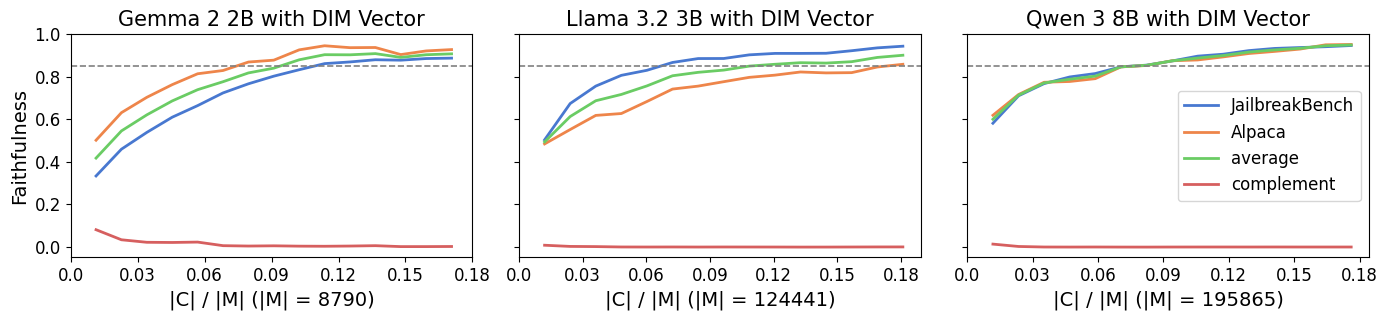

In [32]:
ns_g2 = [100,200,300,400,500,600,700,800,900,1000, 1100, 1200, 1300, 1400, 1500]
ns_l3 = [1500,3000,4500,6000,7500,9000,10500,12000,13500,15000,16500,18000,19500,21000,22500]
ns_q8 = [2300,4600,6900,9200,11500,13800,16100,18400,20700,23000,25300,27600,29900,32200,34500]

g2_dim_logit = get_n_scores(
    g2_model_path,
    ns_g2,
    'ig2_dim_logit'
)
invert_g2_dim_logit = get_n_scores(
    g2_model_path,
    ns_g2,
    'ig2_dim_logit',
    invert=True
)
l3_dim_logit = get_n_scores(
    l3_model_path,
    ns_l3,
    'ig2_dim_logit'
)
invert_l3_dim_logit = get_n_scores(
    l3_model_path,
    ns_l3,
    'ig2_dim_logit',
    invert=True
)

q8_dim_logit = get_n_scores(
    q8_model_path,
    ns_q8,
    'ig2_dim_logit'
)
invert_q8_dim_logit = get_n_scores(
    q8_model_path,
    ns_q8,
    'ig2_dim_logit',
    invert=True
)

# paper ready graph: harmful and harmless g2 ntp
fig, axs = plt.subplots(1,3,figsize=(14,3.3), sharey=True)

palette = sns.color_palette("muted", 4)

g2_data = [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)]
labels = ['JailbreakBench', 'Alpaca', 'average', 'complement']

xs_g2 = [n / num_edges_g2 for n in ns_g2]
xs_l3 = [n / num_edges_l3 for n in ns_l3]
xs_q8 = [n / num_edges_q8 for n in ns_q8]
for scores, label, p_color in zip(g2_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(xs_g2, means,label=label, color=p_color, linewidth=2)

# xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
xticks = [0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18]
tick_size, label_size, title_size, legend_size = 12, 14, 15, 12
axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='y', labelsize=tick_size)
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks, fontsize=tick_size)
axs[0].set_xlabel(f'|C| / |M| (|M| = {num_edges_g2})', fontsize=label_size)
axs[0].set_ylabel('Faithfulness', fontsize=label_size)
axs[0].set_title("Gemma 2 2B with DIM Vector", fontsize=title_size)
# axs[0].set_title("Gemma 2 2B with Difference-in-Means Vector", fontsize=16)

l3_data = [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)]
# l3_data = [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)]
for scores, label, p_color in zip(l3_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(xs_l3, means, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=tick_size)
axs[1].set_xlabel(f'|C| / |M| (|M| = {num_edges_l3})', fontsize=label_size)
axs[1].set_title("Llama 3.2 3B with DIM Vector", fontsize=title_size)
# axs[1].set_title("Llama 3.2 3B with Difference-in-Means Vector", fontsize=16)

q8_data = [q8_dim_logit[0], q8_dim_logit[1], avg(q8_dim_logit), avg(invert_q8_dim_logit)]
for scores, label, p_color in zip(q8_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[2].plot(xs_q8, means, label=label, color=p_color, linewidth=2)
axs[2].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[2].set_xticks(xticks)
axs[2].set_xticklabels(xticks, fontsize=tick_size)
axs[2].set_xlabel(f'|C| / |M| (|M| = {num_edges_q8})', fontsize=label_size)
axs[2].set_title("Qwen 3 8B with DIM Vector", fontsize=title_size)
# axs[2].set_title("Qwen 3 8B with Difference-in-Means Vector", fontsize=16)

axs[2].legend(loc='right', fontsize=legend_size)
plt.tight_layout()
plt.savefig('granular/faith_dim_all3.pdf')
plt.show()
sns.reset_defaults()



### Llama

[(0.4846850794052002, 0.1003297201180217), (0.5524448380297928, 0.10006135961272063), (0.6188456068906308, 0.1021589685759259), (0.627698335179515, 0.0927932191419699), (0.6842258003592919, 0.09279046729780621), (0.7426755912102552, 0.0956755441928977), (0.7565837911835073, 0.09567492837893474), (0.7773630176905425, 0.09666839594397338), (0.7977669801709529, 0.09487685339615587), (0.808165888053986, 0.09634508593655088), (0.8230277752739672, 0.09438929206472384), (0.8186848639485629, 0.08776789186442617), (0.8199202691224313, 0.091041725587616), (0.8463961426125848, 0.08916121872282579), (0.8591448291235888, 0.08555194289816943)]
[0.012053905063443721, 0.024107810126887442, 0.03616171519033116, 0.048215620253774884, 0.0602695253172186, 0.07232343038066232, 0.08437733544410604, 0.09643124050754977, 0.10848514557099348, 0.1205390506344372, 0.13259295569788093, 0.14464686076132463, 0.15670076582476836, 0.16875467088821208, 0.1808085759516558]
saving to granular/faith_l3_dim.pdf


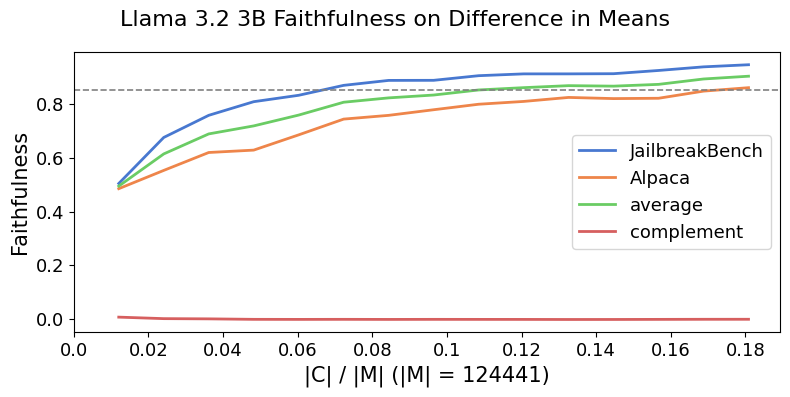

saving to granular/faith_l3_ntp.pdf


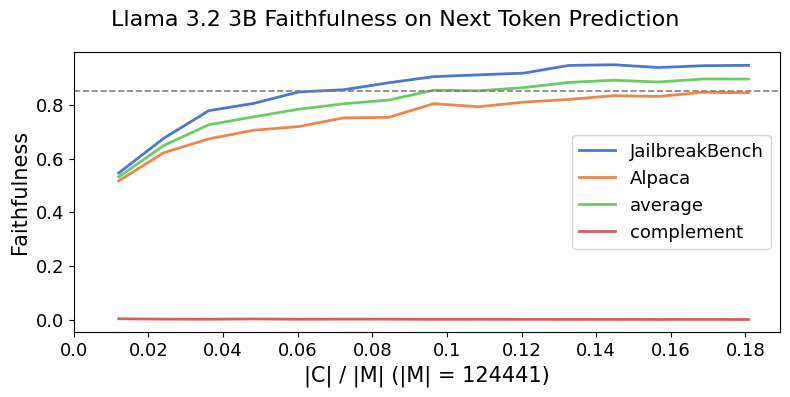

saving to granular/faith_l3_po.pdf


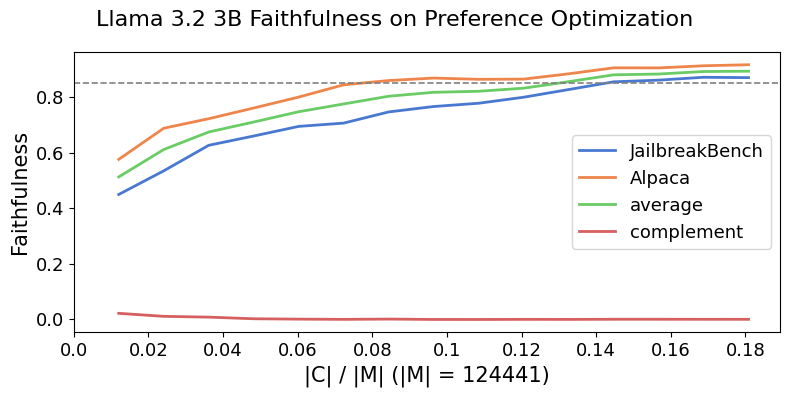

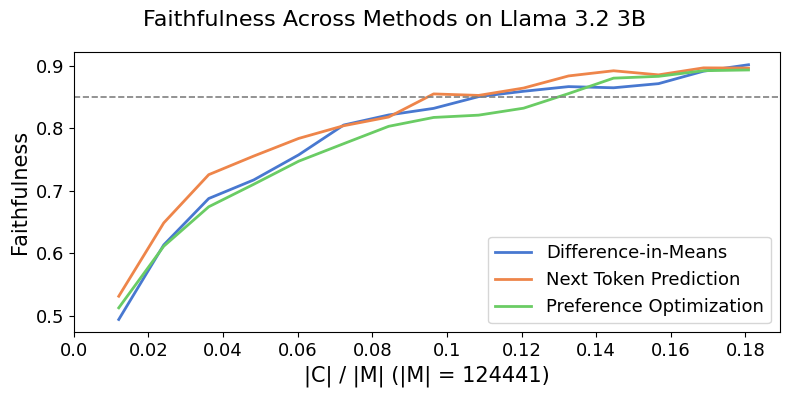

In [52]:
# paper ready graph: harmful and harmless g2 ntp
ns = [1500,3000,4500,6000,7500,9000,10500,12000,13500,15000,16500,18000,19500,21000,22500]

l3_ntp_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_ntp_logit'
)
l3_reps_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_reps_logit'
)
l3_dim_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_dim_logit'
)
l3_invert_ntp_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_ntp_logit',
    invert=True
)
l3_invert_reps_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_reps_logit',
    invert=True
)
l3_invert_dim_logit = get_n_scores(
    l3_model_path,
    ns,
    'ig2_dim_logit',
    invert=True
)
l3_xs = [n / num_edges_l3 for n in ns]
# xticks = [1500, 4500, 7500, 10500, 13500, 16500, 19500, 22500]
xticks = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]
print(l3_dim_logit[1])
print(l3_xs)
line_plot(
    [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(l3_invert_dim_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Llama 3.2 3B Faithfulness on Difference in Means",
    l3_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_l3,
    save_name='granular/faith_l3_dim.pdf'
)
line_plot(
    [l3_ntp_logit[0], l3_ntp_logit[1], avg(l3_ntp_logit), avg(l3_invert_ntp_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Llama 3.2 3B Faithfulness on Next Token Prediction",
    l3_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_l3,
    save_name='granular/faith_l3_ntp.pdf'
)
line_plot(
    [l3_reps_logit[0], l3_reps_logit[1], avg(l3_reps_logit), avg(l3_invert_reps_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Llama 3.2 3B Faithfulness on Preference Optimization",
    l3_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_l3,
    save_name='granular/faith_l3_po.pdf'
)
line_plot(
    [avg(l3_dim_logit), avg(l3_ntp_logit), avg(l3_reps_logit)], 
    ['Difference-in-Means', 'Next Token Prediction', "Preference Optimization"],
    "Faithfulness Across Methods on Llama 3.2 3B",
    l3_xs,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_l3,
    legend_loc='lower right',
)


In [43]:
print(avg(dim_logit))
print(avg(ntp_logit))
print(avg(reps_logit))

[(0.49429433458245614, -1), (0.6135279921493595, -1), (0.6877519829080948, -1), (0.7174593296759064, -1), (0.7575971815373452, -1), (0.8052411272018487, -1), (0.8213602751261541, -1), (0.8319048394182901, -1), (0.8506839735035745, -1), (0.8592431866484835, -1), (0.866693400621884, -1), (0.8648394597034497, -1), (0.8714455226446969, -1), (0.8913879538543187, -1), (0.9016832978831795, -1)]
[(0.5314704474461474, -1), (0.6487239473438596, -1), (0.7258828871629253, -1), (0.7556241168773303, -1), (0.7838516883785309, -1), (0.8041461014437097, -1), (0.8180643208607732, -1), (0.855016354914764, -1), (0.8526365545154043, -1), (0.8644102852457363, -1), (0.8837875148708907, -1), (0.8920398040983389, -1), (0.8854870809662709, -1), (0.8966900677264688, -1), (0.896335383844886, -1)]
[(0.5129256841950927, -1), (0.6114505964556565, -1), (0.6745297836515334, -1), (0.7104962062905327, -1), (0.747423834099798, -1), (0.77542147640223, -1), (0.8032017310903532, -1), (0.8173916839698496, -1), (0.82106877580

In [9]:
dim_ns = [13500]
ntp_ns = [12000]
reps_ns = [16500]
dim_on_ntp_scores = get_n_scores(l3_model_path, dim_ns,
    'ig2_ntp_logit/dim_on_ntp'
)
dim_on_reps_scores = get_n_scores(l3_model_path,
    dim_ns,
    'ig2_reps_logit/dim_on_reps'
)
dim_on_dim_scores = get_n_scores(l3_model_path,
    dim_ns,
    'ig2_dim_logit'
)
dim_on_rand_scores = get_n_scores(l3_model_path,
    [2*n for n in dim_ns],
    'ig2_dim_logit',
    method='random'
)
ntp_on_ntp_scores = get_n_scores(l3_model_path, ntp_ns,
    'ig2_ntp_logit'
)
ntp_on_reps_scores = get_n_scores(l3_model_path,
    ntp_ns,
    'ig2_reps_logit/ntp_on_reps'
)
ntp_on_dim_scores = get_n_scores(l3_model_path,
    ntp_ns,
    'ig2_dim_logit/ntp_on_dim'
)
ntp_on_rand_scores = get_n_scores(l3_model_path,
    [2*n for n in ntp_ns],
    'ig2_ntp_logit',
    method='random'
)
reps_on_ntp_scores = get_n_scores(l3_model_path, reps_ns,
    'ig2_ntp_logit/reps_on_ntp'
)
reps_on_reps_scores = get_n_scores(l3_model_path,
    reps_ns,
    'ig2_reps_logit'
)
reps_on_dim_scores = get_n_scores(l3_model_path,
    reps_ns,
    'ig2_dim_logit/reps_on_dim'
)
reps_on_rand_scores = get_n_scores(l3_model_path,
    [2*n for n in reps_ns],
    'ig2_reps_logit',
    method='random'
)

def avg(scores):
    harmful, harmless = scores
    return (harmful[0][0] + harmless[0][0]) / 2


vector_labels = ['DIM', 'NTP', 'PO']
circuit_labels = ['DIM', 'NTP', 'PO', 'random']


{'DIM': [0.8506839735035745, 0.8256794194871022, 0.7409440884736609, 0.0017075245242308492], 'NTP': [0.8647252239802661, 0.855016354914764, 0.7900112691123706, -0.0010724436486424576], 'PO': [0.8624831839483935, 0.8735828064761961, 0.8555640557702289, 0.02010325288963264]}
[0.8506839735035745, 0.8647252239802661, 0.8624831839483935]
[0.8256794194871022, 0.855016354914764, 0.8735828064761961]
[0.7409440884736609, 0.7900112691123706, 0.8555640557702289]
[0.0017075245242308492, -0.0010724436486424576, 0.02010325288963264]


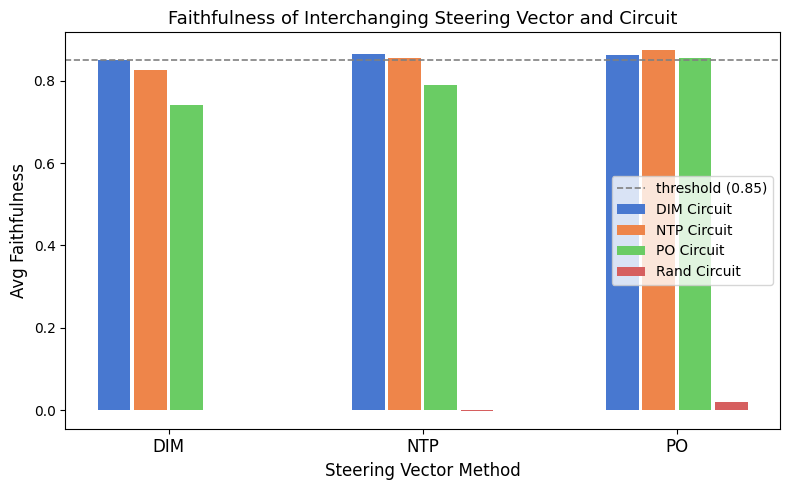

In [10]:
data = {
    'DIM':  [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),
    avg(dim_on_reps_scores),  max(avg(dim_on_rand_scores),0)],
    'NTP':  [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),
    avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':   [avg(reps_on_dim_scores), avg(reps_on_ntp_scores),
   avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
print(data)

circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Rand Circuit']
steer_methods  = list(data.keys())
n_groups  = len(steer_methods)
n_bars    = len(circuit_labels)

x = np.arange(n_groups)*0.7
bar_width = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

palette = sns.color_palette("muted", n_bars)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, color) in enumerate(zip(circuit_labels, palette)):
    heights = [data[m][i] for m in steer_methods]
    print(heights)
    ax.bar(x + offsets[i], heights, width=bar_width*0.9, label=label, color=color)

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2, label='threshold (0.85)')
ax.set_xticks(x)
ax.set_xticklabels(steer_methods, fontsize=12)
ax.set_ylabel('Avg Faithfulness', fontsize=12)
ax.set_xlabel('Steering Vector Method', fontsize=12)
ax.set_title('Faithfulness of Interchanging Steering Vector and Circuit', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

[0.49429433 0.61352799 0.68775198 0.71745933 0.75759718 0.80524113
 0.82136028 0.83190484 0.85068397 0.85924319 0.8666934  0.86483946
 0.87144552 0.89138795 0.9016833 ]
[0.012053905063443721, 0.024107810126887442, 0.03616171519033116, 0.048215620253774884, 0.0602695253172186, 0.07232343038066232, 0.08437733544410604, 0.09643124050754977, 0.10848514557099348, 0.1205390506344372, 0.13259295569788093, 0.14464686076132463, 0.15670076582476836, 0.16875467088821208, 0.1808085759516558]
[0.53147045 0.64872395 0.72588289 0.75562412 0.78385169 0.8041461
 0.81806432 0.85501635 0.85263655 0.86441029 0.88378751 0.8920398
 0.88548708 0.89669007 0.89633538]
[0.012053905063443721, 0.024107810126887442, 0.03616171519033116, 0.048215620253774884, 0.0602695253172186, 0.07232343038066232, 0.08437733544410604, 0.09643124050754977, 0.10848514557099348, 0.1205390506344372, 0.13259295569788093, 0.14464686076132463, 0.15670076582476836, 0.16875467088821208, 0.1808085759516558]
[0.51292568 0.6114506  0.6745297

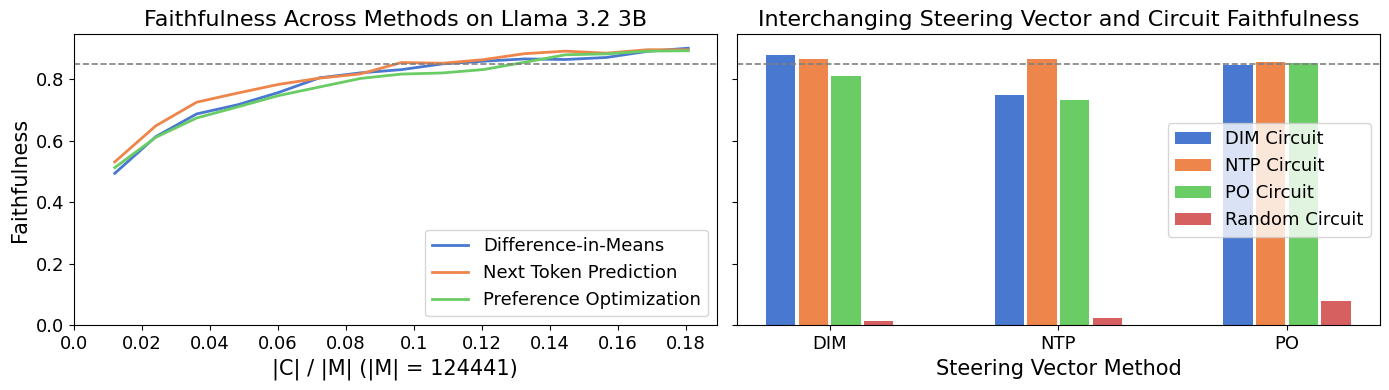

In [35]:
# Combined figure: "Faithfulness Across Methods" (line) + "Interchanging Steering Vector and Circuit" (bar)
ns_line = [1500,3000,4500,6000,7500,9000,10500,12000,13500,15000,16500,18000,19500,21000,22500]
avg_list = lambda x: [((a[0]+b[0])/2, -1) for a, b in zip(x[0], x[1])]

line_data   = [avg_list(l3_dim_logit), avg_list(l3_ntp_logit), avg_list(l3_reps_logit)]
line_labels = ['Difference-in-Means', 'Next Token Prediction', 'Preference Optimization']

bar_data = {
    'DIM': [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),  avg(dim_on_reps_scores),  max(0,avg(dim_on_rand_scores))],
    'NTP': [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),  avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':  [avg(reps_on_dim_scores), avg(reps_on_ntp_scores), avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
bar_circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Random Circuit']
steer_methods = list(bar_data.keys())

palette = sns.color_palette("muted", 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left: line plot ---
l3_xs = [n / num_edges_l3 for n in ns_line]
for scores, label, color in zip(line_data, line_labels, palette[:3]):
    means = np.array([s[0] for s in scores])
    print(means)
    print(l3_xs)
    ax1.plot(l3_xs, means, marker=None, label=label, linewidth=2, color=color)
ax1.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)

xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=13)
ax1.set_xlabel(f'|C| / |M| (|M| = {num_edges_l3})', fontsize=15)
ax1.set_ylabel('Faithfulness', fontsize=15)
ax1.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)
ax1.set_title('Faithfulness Across Methods on Llama 3.2 3B', fontsize=16)
ax1.legend(fontsize=13, loc='lower right')

# --- Right: grouped bar plot ---
x = np.arange(len(steer_methods)) * 0.7
bar_width = 0.10
offsets = np.linspace(-(len(bar_circuit_labels)-1)/2, (len(bar_circuit_labels)-1)/2, len(bar_circuit_labels)) * bar_width

for i, (label, color) in enumerate(zip(bar_circuit_labels, palette)):
    heights = [bar_data[m][i] for m in steer_methods]
    print(heights)
    ax2.bar(x + offsets[i], heights, width=bar_width * 0.9, label=label, color=color)

ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(steer_methods, fontsize=13)
ax2.set_xlabel('Steering Vector Method', fontsize=15)
ax2.set_title('Interchanging Steering Vector and Circuit Faithfulness', fontsize=16)
ax2.legend(fontsize=13, loc='right')

plt.tight_layout()
plt.savefig("granular/faith_methods_combined_l3.pdf", bbox_inches='tight')
plt.show()


### Qwen 3 8B

[(0.6007340783550047, -1), (0.7139503194732495, -1), (0.7714931577729369, -1), (0.788939885674095, -1), (0.8036412774666091, -1), (0.8470892339265668, -1), (0.8543466319373855, -1), (0.8752535816135916, -1), (0.888512024398747, -1), (0.9002814402777763, -1), (0.9166609834180774, -1), (0.9266996627190012, -1), (0.9343058984607495, -1), (0.9463181351056609, -1), (0.9499039527703708, -1)]
saving to granular/faith_q8_dim.pdf


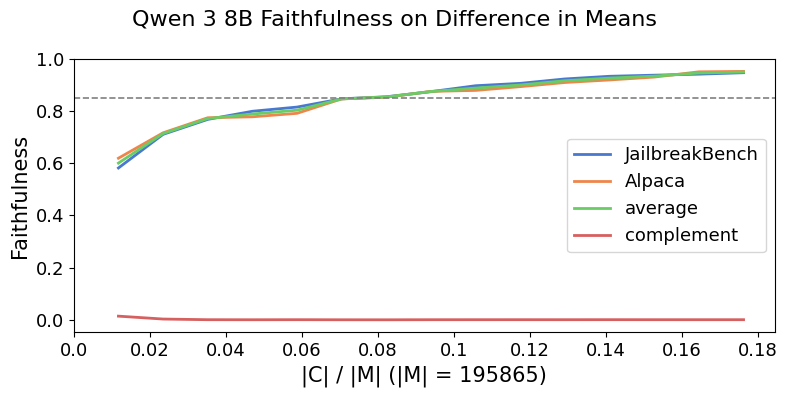

In [34]:
# paper ready graph: harmful and harmless g2 ntp
ns_q8 = [2300,4600,6900,9200,11500,13800,16100,18400,20700,23000,25300,27600,29900,32200,34500]

q8_dim_logit = get_n_scores(
    q8_model_path,
    ns_q8,
    'ig2_dim_logit'
)
invert_q8_dim_logit = get_n_scores(
    q8_model_path,
    ns_q8,
    'ig2_dim_logit',
    invert=True
)
xticks = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
# xticks = [100,300,500,700,900,1100,1300,1500]

q8_xs = [n / num_edges_q8 for n in ns_q8]
print(avg(q8_dim_logit))
avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]
line_plot(
    [q8_dim_logit[0], q8_dim_logit[1], avg(q8_dim_logit), avg(invert_q8_dim_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Qwen 3 8B Faithfulness on Difference in Means",
    q8_xs,
    # ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    num_edges=num_edges_q8,
    save_name='granular/faith_q8_dim.pdf'
)